In [1]:

import os
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Add the path to the modeling_pipeline.py
sys.path.append('/home/feven/Documents/Fraud Detection/src')

# Import necessary functions from modeling_pipeline.py
from modeling_pipeline import (
    prepare_creditcard_dataset,
    prepare_fraud_dataset,
    describe_dataset,
    split_scale_resample,
    evaluate_model,
    tune_xgboost,
    plot_feature_importance,
    shap_explainability
)


import os
import pandas as pd
import shap
from xgboost import XGBClassifier
from modeling_pipeline import (
    prepare_creditcard_dataset,
    split_scale_resample,
    shap_explainability
)

warnings.filterwarnings('ignore')
ROOT_DIR = Path.cwd()


/home/feven/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Dataset: CreditCard
Rows: 50,000, Features: 8
Target class distribution:
Class
0    49777
1      223
Percent distribution:
Class
0    99.554
1     0.446
Imbalance ratio (normal : fraud) = 223.2 : 1
------------------------------------------------------------------------
Training set before resampling: [39822   178]
Training set after SMOTE: [39822 39822]
------------------------------------------------------------------------
CreditCard | LogisticRegression | AP: 0.0304 | F1: 0.0229 | ROC-AUC: 0.7917
Confusion matrix:
[[7409 2546]
 [  15   30]]
------------------------------------------------------------------------
Tuning XGBoost with stratified CV (SMOTE inside each fold)...
  Fold 1 | AP 0.0291 | F1 0.0574 | ROC-AUC 0.7490
  Fold 2 | AP 0.0310 | F1 0.0474 | ROC-AUC 0.6331
  Fold 3 | AP 0.0221 | F1 0.0315 | ROC-AUC 0.6831
  Fold 4 | AP 0.0090 | F1 0.0196 | ROC-AUC 0.5909
  Fold 5 | AP 0.0190 | F1 0.0435 | ROC-AUC 0.6588
Cross-validation summary: {'mean_average_precision': np.floa

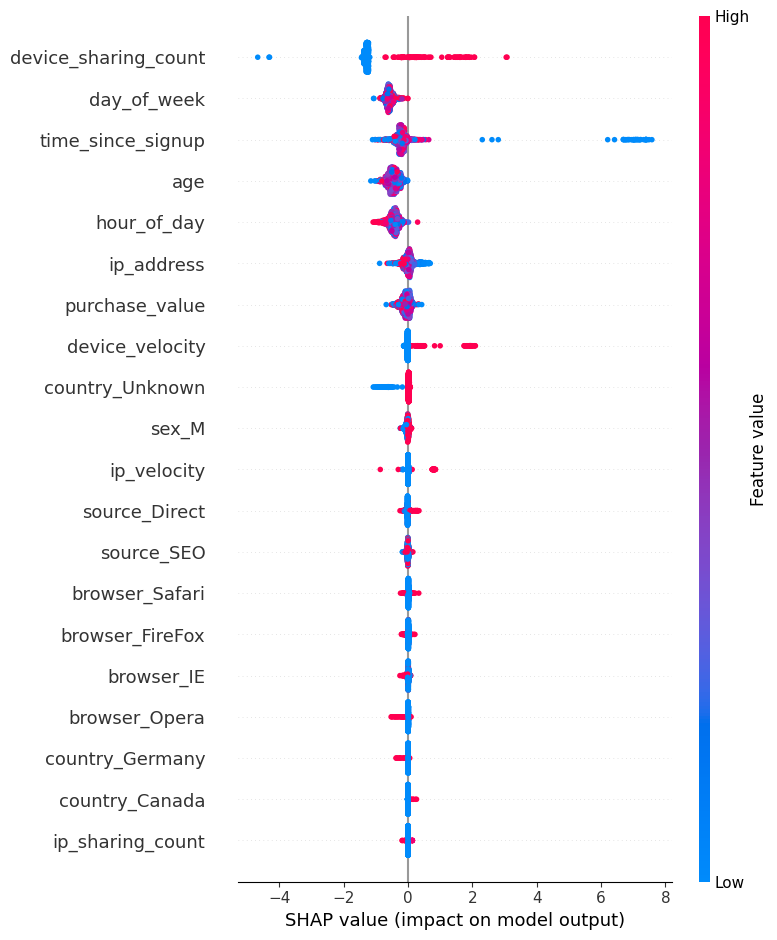

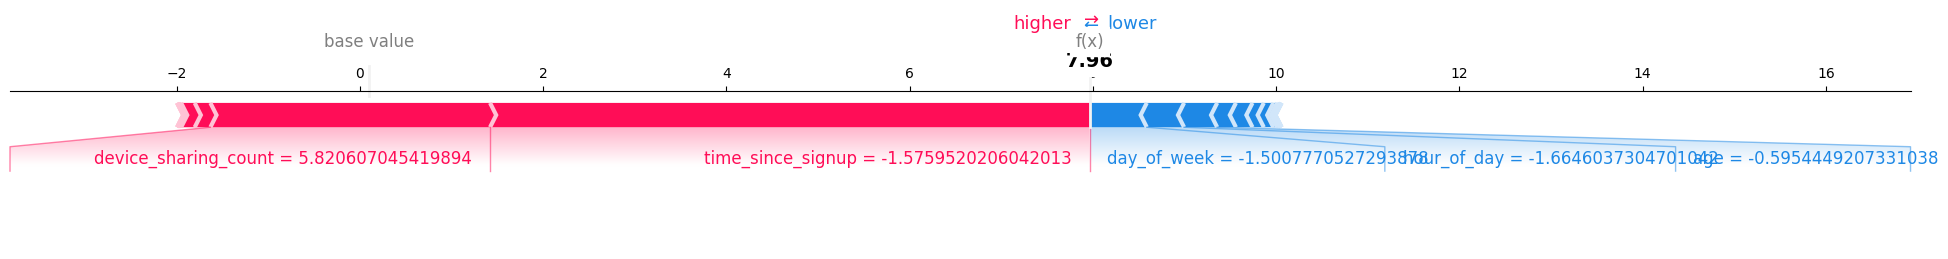

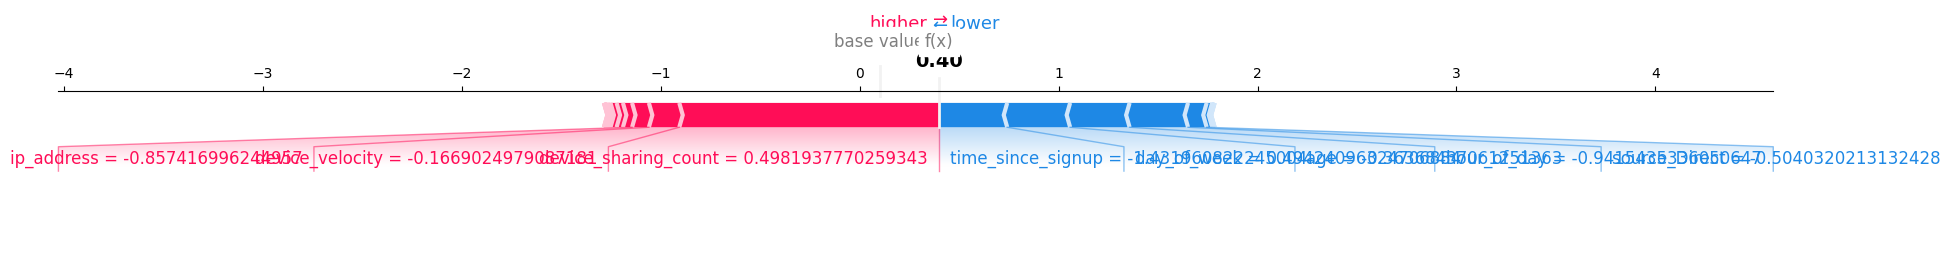

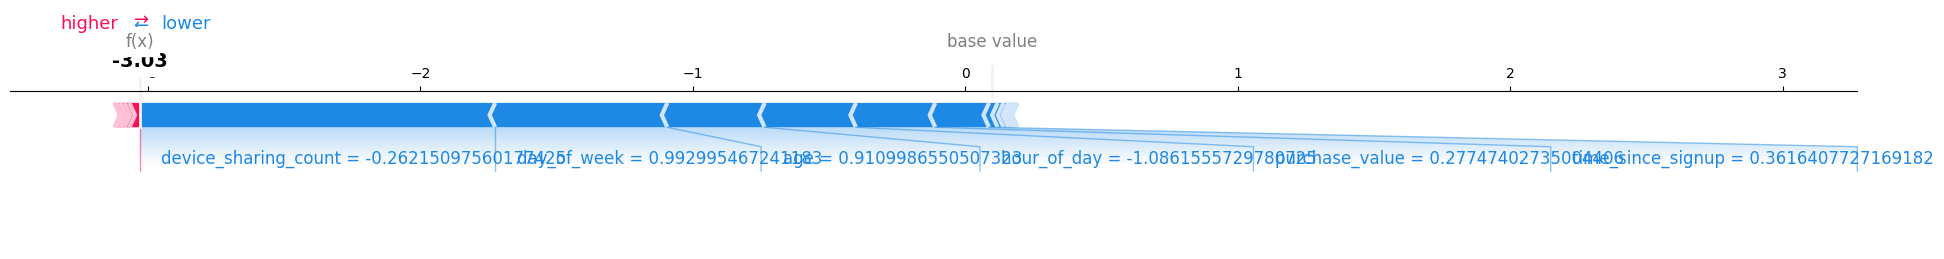

Saved model comparison summary to /home/feven/Documents/Fraud Detection/notebooks/models/reports/model_comparison_summary.csv
      dataset               model  average_precision  f1_score   roc_auc  \
0  CreditCard  LogisticRegression           0.030436  0.022892  0.791696   
1  CreditCard             XGBoost           0.018561  0.055202  0.712149   
2   FraudData  LogisticRegression           0.670783  0.605047  0.835548   
3   FraudData             XGBoost           0.704292  0.684114  0.831086   

      tn    fp    fn    tp  
0   7409  2546    15    30  
1   9542   413    32    13  
2  25635  1758   840  1990  
3  27357    36  1340  1490  


In [2]:

def run_pipeline():
    results = []
    output_dir = ROOT_DIR / 'models' / 'reports'
    output_dir.mkdir(parents=True, exist_ok=True)

    dataset_configs = [
        ('CreditCard', prepare_creditcard_dataset),
        ('FraudData', prepare_fraud_dataset),
    ]

    for dataset_name, prepare_fn in dataset_configs:
        X, y = prepare_fn('data/processed')
        describe_dataset(dataset_name, X, y)

        X_train_scaled, X_test_scaled, y_train, y_test, X_train_res, y_train_res, scaler = split_scale_resample(X, y)

        baseline = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
        baseline.fit(X_train_res, y_train_res)
        results.append(evaluate_model(baseline, X_test_scaled, y_test, 'LogisticRegression', dataset_name))

        # Tune XGBoost on the full dataset and then fit the best ensemble on the train split.
        best_params = tune_xgboost(X, y)
        ensemble = XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            n_jobs=-1,
            random_state=42,
            **best_params,
        )
        ensemble.fit(X_train_res, y_train_res)
        results.append(evaluate_model(ensemble, X_test_scaled, y_test, 'XGBoost', dataset_name))

        # Save feature importance for the chosen model
        feature_names = X.columns.tolist()
        importance = plot_feature_importance(ensemble, feature_names, save_path=output_dir / f'{dataset_name}_feature_importance.png')
        importance.to_csv(output_dir / f'{dataset_name}_feature_importance.csv')

        # Save the best model to disk for later explainability if it's the fraud dataset.
        if dataset_name == 'FraudData':
            import joblib
            joblib.dump(ensemble, ROOT_DIR / 'models' / 'best_fraud_xgb.joblib')
            print('Saved FraudData ensemble model artifact.')

            shap_dir = ROOT_DIR / 'models' / 'shap_fraud'
            X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
            shap_explainability(ensemble, X_test_df, y_test.reset_index(drop=True), feature_names, shap_dir)

    summary_df = pd.DataFrame(results)
    summary_path = output_dir / 'model_comparison_summary.csv'
    summary_df.to_csv(summary_path, index=False)
    print(f'Saved model comparison summary to {summary_path}')
    print(summary_df)

# Run the pipeline
run_pipeline()


In [3]:

# Prepare the dataset
X, y = prepare_creditcard_dataset('data/processed')
X_train_scaled, X_test_scaled, y_train, y_test, X_train_res, y_train_res, scaler = split_scale_resample(X, y)

# Train the model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train_res, y_train_res)


Training set before resampling: [39822   178]
Training set after SMOTE: [39822 39822]
------------------------------------------------------------------------


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'
